In [131]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.cluster import KMeans
import plotly.express as px
from scipy.stats.mstats import trimmed_var
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [132]:
df=pd.read_csv("/content/SCFP2019.csv")
df.head()

,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
0,1,11,6119.779308,2,75,6,12,4,2,0,...,5,3,6,3,2,10,6,6,3,3
1,1,12,4712.374912,2,75,6,12,4,2,0,...,5,3,6,3,1,10,5,5,2,2
2,1,13,5145.224455,2,75,6,12,4,2,0,...,5,3,6,3,1,10,5,5,2,2
3,1,14,5297.663412,2,75,6,12,4,2,0,...,5,2,6,2,1,10,4,4,2,2
4,1,15,4761.812371,2,75,6,12,4,2,0,...,5,3,6,3,1,10,5,5,2,2


In [133]:
mask = df['TURNFEAR']==1
df_fear=df[mask]
print('df_fear shape :',df_fear.shape)
df_fear.head()

df_fear shape : (4623, 351)


,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
5,2,21,3790.476607,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
6,2,22,3798.868505,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,3,2,2
7,2,23,3799.468393,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
8,2,24,3788.076005,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
9,2,25,3793.066589,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2


In [134]:
age_groups = df_fear['AGECL'].unique()
print('Age Groups:', age_groups)

Age Groups: [3 5 1 2 4 6]


In [135]:
agecl_dict = {
    1:"Under 35",
    2:"35-44",
    3:"45-54",
    4:"55-64",
    5:"65-74",
    6:"75 or Older"
}
age_cl = df_fear["AGECL"].replace(agecl_dict)
age_cl.head(10)

,AGECL
5,45-54
6,45-54
7,45-54
8,45-54
9,45-54
110,65-74
111,65-74
112,65-74
113,65-74
114,65-74


<Axes: xlabel='AGECL'>

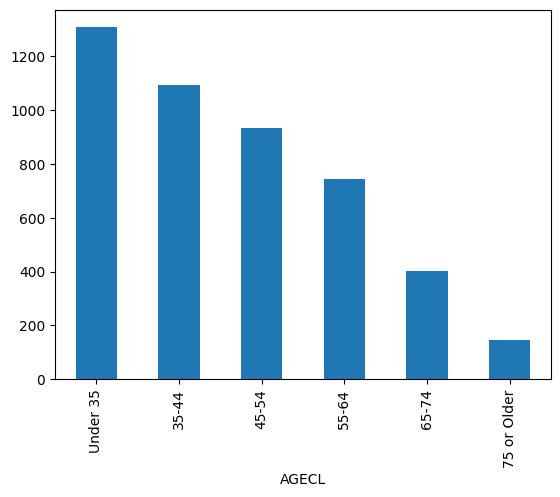

In [136]:
age_cl.value_counts=age_cl.value_counts()
age_cl.value_counts.plot(kind='bar')

<Axes: >

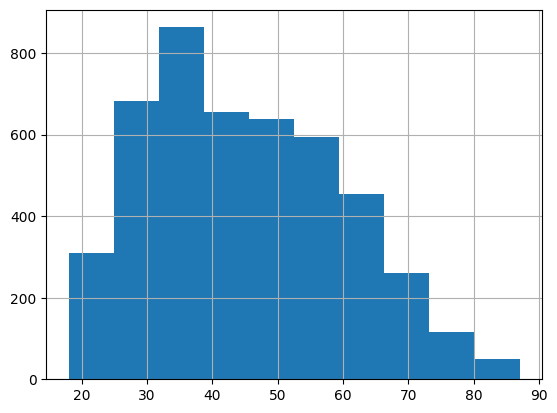

In [137]:
df_fear['AGE'].hist(bins=10)

In [138]:
inccat_dict={
    1:"0-20",
    2:"20-39.9",
    3:"40-59.9",
    4:"60-79.9",
    5:"80-89.9",
    6:"90-100"
}
inccat=df_fear["INCCAT"].replace(inccat_dict)
inccat.head(10)

,INCCAT
5,20-39.9
6,20-39.9
7,20-39.9
8,20-39.9
9,20-39.9
110,0-20
111,0-20
112,0-20
113,0-20
114,0-20


<Axes: xlabel='INCCAT'>

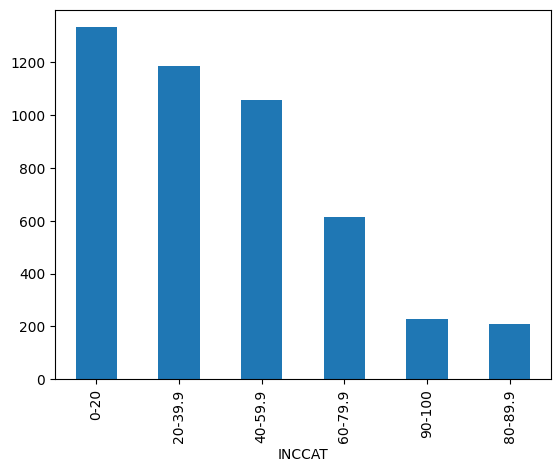

In [139]:
inccat_val_counts=inccat.value_counts()
inccat_val_counts.plot(kind='bar')

In [140]:
columns = ["ASSET","HOUSES","INCOME","DEBT","EDUC"]
corr = df[columns].corr()
corr.style.background_gradient(axis=None)

,ASSET,HOUSES,INCOME,DEBT,EDUC
ASSET,1.000000,0.519827,0.622429,0.261250,0.116673
HOUSES,0.519827,1.000000,0.247852,0.266661,0.169300
INCOME,0.622429,0.247852,1.000000,0.114646,0.069400
DEBT,0.261250,0.266661,0.114646,1.000000,0.054179
EDUC,0.116673,0.169300,0.069400,0.054179,1.000000


In [141]:
corr_fear = df_fear[columns].corr()
corr_fear.style.background_gradient(axis=None)

,ASSET,HOUSES,INCOME,DEBT,EDUC
ASSET,1.000000,0.583288,0.722074,0.474658,0.113536
HOUSES,0.583288,1.000000,0.264099,0.962629,0.160348
INCOME,0.722074,0.264099,1.000000,0.172393,0.133170
DEBT,0.474658,0.962629,0.172393,1.000000,0.177386
EDUC,0.113536,0.160348,0.133170,0.177386,1.000000


<Figure size 1200x600 with 0 Axes>

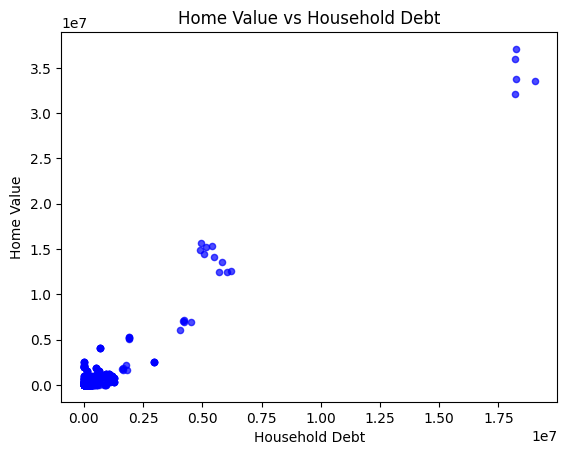

In [142]:
plt.figure(figsize=(12,6))
df_fear.plot.scatter(x='DEBT',y='HOUSES',c='blue',alpha=0.7,marker="o")
plt.xlabel('Household Debt')
plt.ylabel('Home Value')
plt.title('Home Value vs Household Debt')
plt.show()

In [143]:
df['TURNFEAR'].value_counts()

,count
TURNFEAR,
0,24262
1,4623


In [144]:
features= ["AGE","INCCAT","NWCAT","ASSETCAT"]
x= df[features]
x=x.dropna()

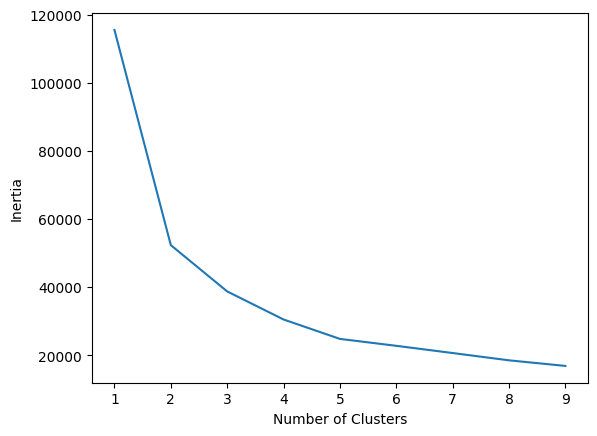

In [145]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

inertia = []
for k in range(1,10):
     model = KMeans(n_clusters=k, random_state=42, n_init='auto')
     model.fit(X_scaled)
     inertia.append(model.inertia_)

plt.plot(range(1,10),inertia)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [146]:
from sklearn.cluster import KMeans
kMeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kMeans.fit(X_scaled)
clusters = kMeans.labels_
x['Cluster'] = clusters
x.groupby('Cluster').mean()

,AGE,INCCAT,NWCAT,ASSETCAT
Cluster,,,,
0,59.049449,5.367666,4.606200,5.567000
1,36.359261,2.621108,1.642111,1.996412
2,65.100766,2.319829,2.509934,2.832489


In [147]:
labels= model.labels_
labels[:10]

array([2, 2, 2, 2, 2, 1, 1, 1, 1, 1], dtype=int32)

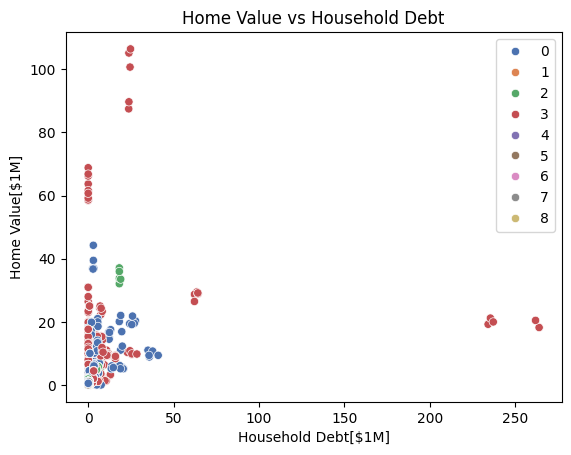

In [148]:
sns.scatterplot(
    x=df['DEBT']/1e6,
    y= df['HOUSES']/1e6,
    hue=labels, # Use labels corresponding to df_fear
    palette='deep'
)

plt.xlabel('Household Debt[$1M]')
plt.ylabel('Home Value[$1M]')
plt.title('Home Value vs Household Debt')
plt.show()

In [149]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score
from sklearn.pipeline import Pipeline

In [150]:
RANDOM_STATE = 42
TARGET = "TURNDOWN"

In [151]:
# Numeric / ordinal-coded features (passed straight through)
NUMERIC_COLS = [
    "AGE", "EDUC", "KIDS", "INCOME", "NETWORTH", "ASSET", "DEBT",
    "DEBT2INC", "CCBAL", "HOMEEQ",
    "MARRIED", "LF", "HHSEX", "LATE", "LATE60", "BNKRUPLAST5", "FORECLLAST5",
]

# True nominal-categorical features (one-hot encoded)
CATEGORICAL_COLS = ["RACE"]

FEATURE_COLUMNS = NUMERIC_COLS + CATEGORICAL_COLS

In [152]:
def build_pipeline(estimator):
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), NUMERIC_COLS),
            ("cat", Pipeline([
                ("impute", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), CATEGORICAL_COLS),
        ]
    )
    return Pipeline([
        ("preprocess", preprocessor),
        ("model", estimator),
    ])

In [157]:
def train_and_save(csv_path: str = "SCFP2019.csv", model_path: str = "model.pkl"):
    df = pd.read_csv(csv_path)
    df = df[df["Y1"] % 10 == 1].copy()

    # Restrict to people who actually applied for credit (see module docstring)
    df = df[df["CRDAPP"] == 1].copy()

    # Metadata for building the Streamlit form dynamically from the training data
    numeric_stats = {
        col: {"min": float(df[col].min()), "max": float(df[col].max()), "mean": float(df[col].mean())}
        for col in NUMERIC_COLS
    }

    categorical_options = {
        col: sorted(df[col].dropna().unique().tolist()) for col in CATEGORICAL_COLS
    }

    X = df[FEATURE_COLUMNS]
    y = df[TARGET]

    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    candidates = {
        "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
        "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    }

    cv_scores = {}
    print("\n--- Model Comparison (Cross-validation) ---")
    for name, est in candidates.items():
        pipe = build_pipeline(est)
        scores = cross_val_score(pipe, x_train, y_train, cv=5, scoring="roc_auc")
        cv_scores[name] = scores.mean()
        print(f"{name:18s}: ROC-AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")

    best_name = max(cv_scores, key=cv_scores.get)
    print(f"\nBest candidate by CV: {best_name}")

    # Plot Model Comparison
    plt.figure(figsize=(7,4))
    plt.bar(cv_scores.keys(), cv_scores.values())
    plt.ylabel("ROC-AUC")
    plt.title("Model Comparison")
    plt.show()

    param_grids = {
        "LogisticRegression": {
            "model__C": [0.1, 1.0, 10.0],
        },
        "RandomForest": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [4, 6, 8, None],
            "model__min_samples_leaf": [1, 2, 4],
        },
        "GradientBoosting": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [2, 3, 4],
            "model__learning_rate": [0.03, 0.05, 0.1],
        },
    }

    best_pipeline = build_pipeline(candidates[best_name])
    grid_params = param_grids.get(best_name, {})

    print(f"\n--- Fine-tuning {best_name} with GridSearchCV ---")
    grid_search = GridSearchCV(
        best_pipeline,
        param_grid=grid_params,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1, # Use all available cores
        verbose=1,
    )

    grid_search.fit(x_train, y_train)

    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best ROC-AUC score: {grid_search.best_score_:.4f}")

    # Evaluate on test set
    best_pipeline = grid_search.best_estimator_
    y_pred = best_pipeline.predict(x_test)
    y_proba = best_pipeline.predict_proba(x_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print(f"\n--- Test Set Evaluation ---")
    print(f"Model        : {best_name}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test ROC-AUC : {roc_auc:.4f}")
    print(f"Precision    : {precision:.4f}")
    print(f"Recall       : {recall:.4f}  <- how many actual rejections we catch")

    # Plot Confusion Matrix
    plt.figure(figsize=(6,6))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )
    plt.title("Confusion Matrix")
    plt.show()

    # Plot ROC Curve
    plt.figure(figsize=(6,6))
    RocCurveDisplay.from_predictions(
        y_test,
        y_proba
    )
    plt.title("ROC Curve")
    plt.show()

    # Plot Model Performance Metrics
    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "ROC-AUC": roc_auc
    }
    plt.figure(figsize=(7,4))
    plt.bar(metrics.keys(), metrics.values())
    plt.ylim(0,1)
    plt.title("Model Performance")
    plt.show()

    # Plot Feature Importance (if applicable)
    if best_name != "LogisticRegression": # Logistic Regression does not have feature_importances_
        try:
            feature_names = best_pipeline.named_steps["preprocess"].get_feature_names_out()
            importances = best_pipeline.named_steps["model"].feature_importances_
            indices = importances.argsort()[::-1]

            plt.figure(figsize=(10,6))
            plt.bar(range(len(importances)), importances[indices])
            plt.xticks(
                range(len(importances)),
                feature_names[indices],
                rotation=90
            )
            plt.title("Feature Importance")
            plt.tight_layout()
            plt.show()
        except AttributeError: # In case the model does not have feature_importances_
            print(f"\nFeature importances are not available for {best_name}")

    # Save the best model with metadata
    joblib.dump(
        {
            "pipeline": best_pipeline,
            "model_name": best_name,
            "accuracy": accuracy,
            "roc_auc": roc_auc,
            "precision": precision,
            "recall": recall,
            "feature_columns": FEATURE_COLUMNS,
            "numeric_stats": numeric_stats,
            "categorical_options": categorical_options,
        },
        model_path,
    )

    print(f"\nModel and metadata saved to '{model_path}'")


In [154]:
    # Metadata for building the Streamlit form dynamically from the training data
    numeric_stats = {
        col: {"min": float(df[col].min()), "max": float(df[col].max()), "mean": float(df[col].mean())}
        for col in NUMERIC_COLS
    }

    categorical_options = {
        col: sorted(df[col].dropna().unique().tolist()) for col in CATEGORICAL_COLS
    }

LogisticRegression: ROC-AUC = 0.6789 (+/- 0.0280)
RandomForest      : ROC-AUC = 0.7644 (+/- 0.0175)
GradientBoosting  : ROC-AUC = 0.7708 (+/- 0.0182)

Best candidate by CV: GradientBoosting

Fine-tuning GradientBoosting with GridSearchCV...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 300}
Best ROC-AUC score: 0.7747

Model        : GradientBoosting
Test Accuracy: 0.8241
Test ROC-AUC : 0.7769
Precision    : 0.5000
Recall       : 0.1574  <- how many actual rejections we catch


<Figure size 600x600 with 0 Axes>

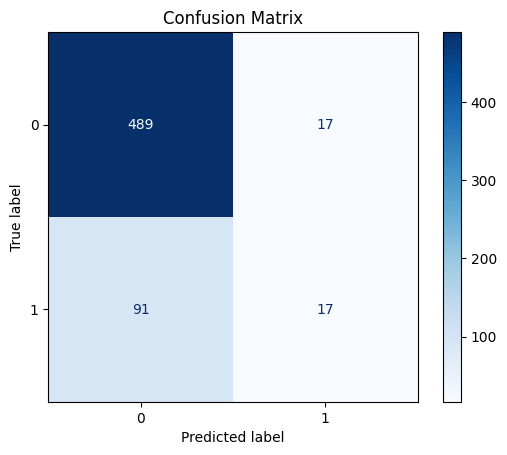


Model and metadata saved to 'model.pkl'


In [155]:
if __name__ == "__main__":
    train_and_save()